In [2]:
coco_path = "/home/maelic/Documents/OpenVocSGG/all_annotations/O365 (pseudo)/RLIPv2_o365trainval_Tagger2_Noi24_20e_Xattnmask_SceneGraph_model_large_caption_nucleus10_thre05_1234_4.json"

#coco_path = "/home/maelic/Documents/OpenVocSGG/all_annotations/COCO (pseudo)/RLIPv2_train2017_threshold20_Tagger2_Noi24_20e_Xattnmask_SceneGraph_model_large_caption_nucleus10_thre05.json"
generated_data = "/home/maelic/Documents/OpenVocSGG/all_annotations/vg150_full.json"
#coco_path = "/home/maelic/Downloads/all_annotations_coco/scene_graphs_preprocessv1.json"
coco_img_path = "/home/maelic/Documents/Datasets/coco/coco/"
vg_img_path = "/home/maelic/Documents/Datasets/VG_100K/"

o365_path = "/home/maelic/Documents/OpenVocSGG/object365/images/"

import json
import os

with open(generated_data, 'r') as f:
    data = json.load(f)

# get the average number of rel per image
from tqdm import tqdm
from collections import Counter
import numpy as np
import random
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from utils import visualize_graph

rel_count = 0
count_predicate = Counter()
num_rels = []

for i in tqdm(data):
    rel_count += len(i['relationships'])
    num_rels.append(len(i['relationships']))

    for r in i['relationships']:
        count_predicate[r['predicate']] += 1

# print number of 0 in num_rels
print("Number of images with 0 relationships: ", num_rels.count(0))
# in % of total
print("Percentage of images with 0 relationships: ", num_rels.count(0)/len(num_rels)*100)

# remove 0 in num_rels
num_rels = [x for x in num_rels if x != 0]
print("Average number of relationships per image: ", np.mean(num_rels))
# median
print("Median number of relationships per image: ", np.median(num_rels))
print("Max number of relationships per image: ", np.max(num_rels))
print("Min number of relationships per image: ", np.min(num_rels))

100%|██████████| 108073/108073 [00:00<00:00, 431037.83it/s]

Number of images with 0 relationships:  29793
Percentage of images with 0 relationships:  27.56747753833057
Average number of relationships per image:  5.149003576903423
Median number of relationships per image:  4.0
Max number of relationships per image:  43
Min number of relationships per image:  1


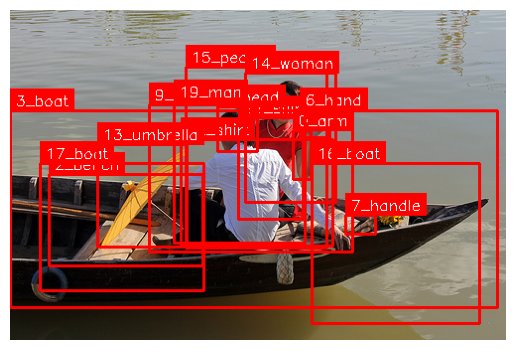

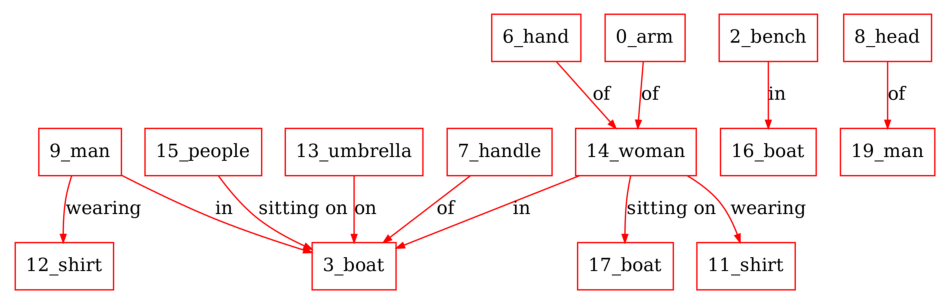

In [5]:
while True:
    img_data = random.choice(data)
    if len(img_data['relationships']) > 0:
        break
img_id = img_data['image_id']
# put a lot of 0 in front of the id such that the total length is 12
img_id = str(img_id)
#img_id = "objects365_v2_" + img_id
split = img_data['data_split']

data_path =vg_img_path

# get corresponding img path
img_path = os.path.join(data_path, str(img_id) + ".jpg")

img = Image.open(img_path)

to_remove = []
for r in img_data['relationships']:
    if r['predicate'] == None:
        to_remove.append(r)
        print(r)

img_data['relationships'] = [x for x in img_data['relationships'] if x not in to_remove]

img_graph, img_boxes = visualize_graph(img_data['relationships'], img_data['objects'], img)

# visualize the box image
plt.imshow(img_boxes)
plt.axis('off')
plt.show()

# visualize the graph
fig = plt.figure(figsize=(12, 12))
plt.imshow(img_graph)
plt.axis('off')
plt.show()

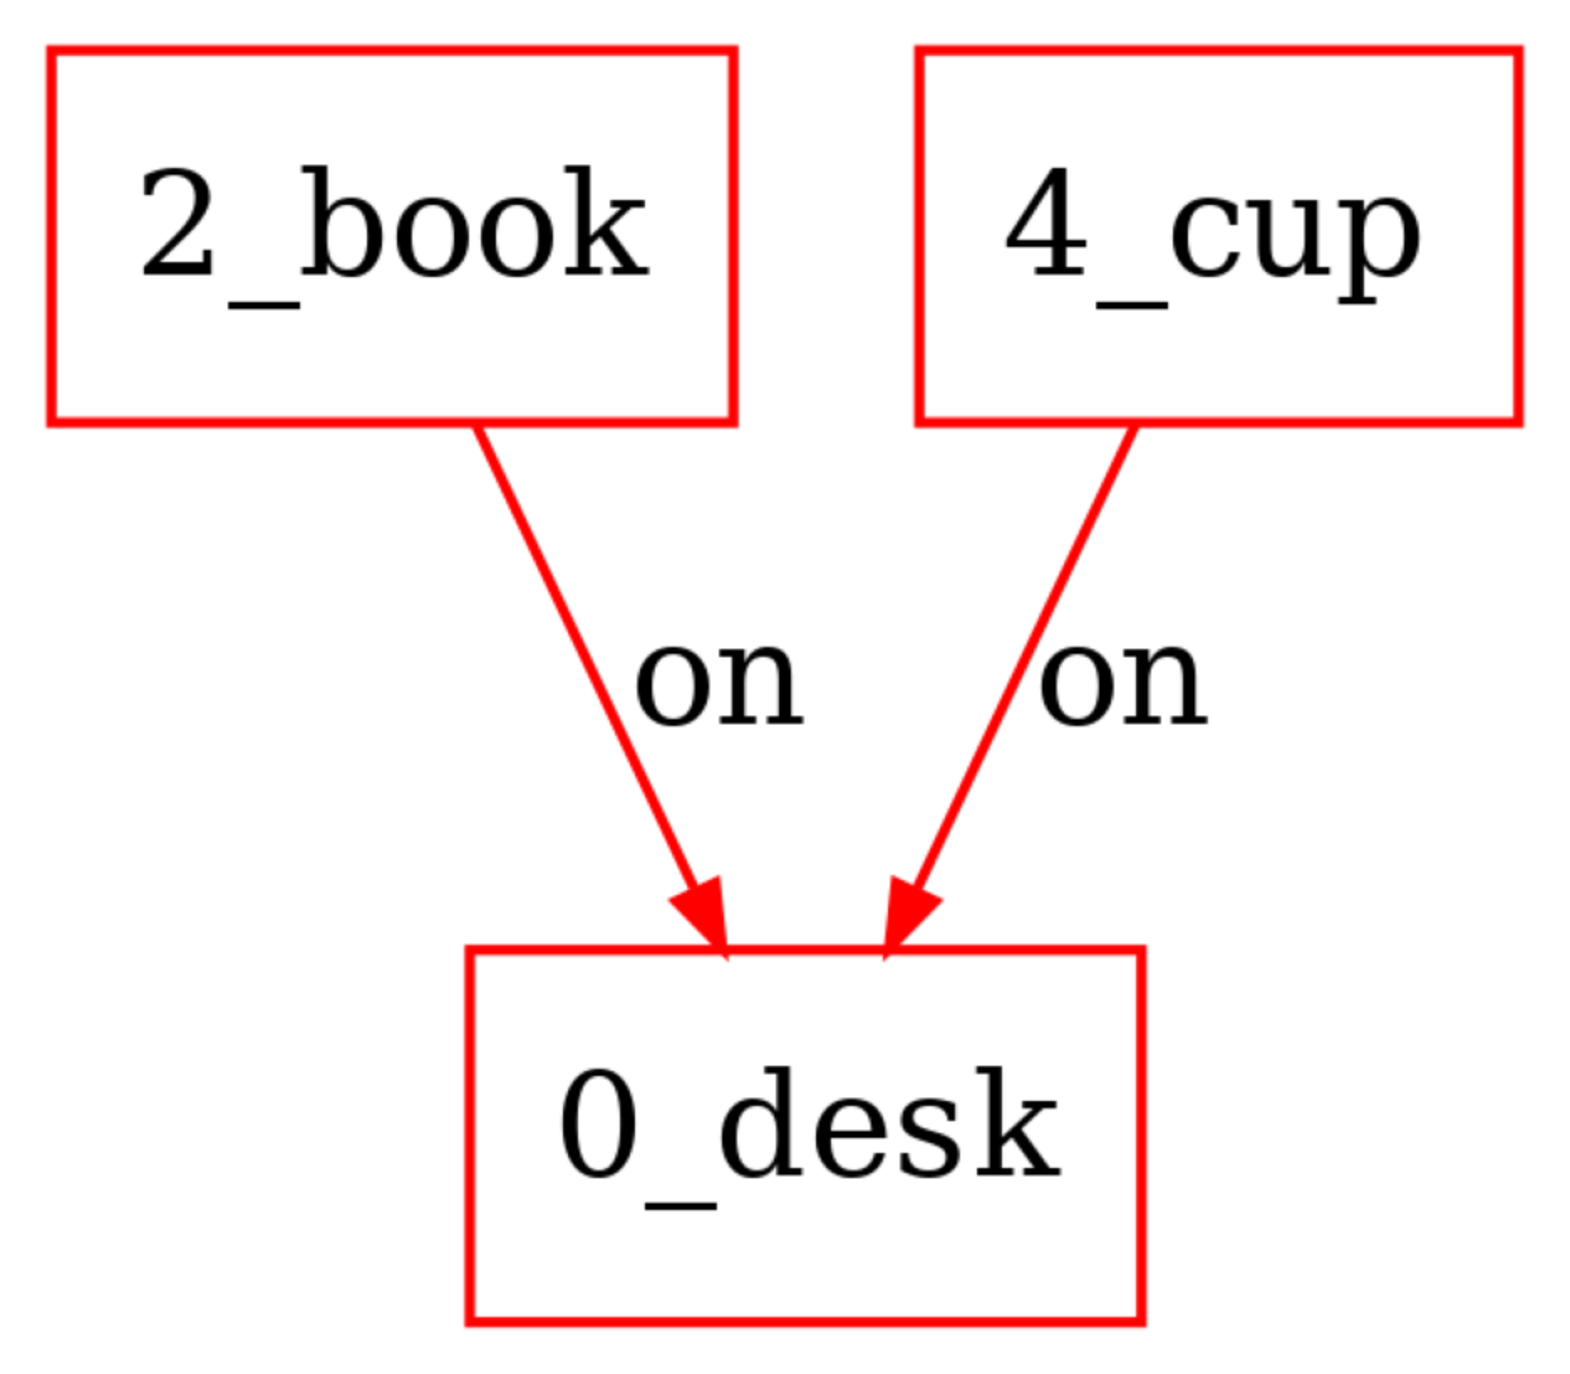

In [3]:
# visualize the graph
fig = plt.figure(figsize=(20, 20))
plt.imshow(img_graph)
plt.axis('off')
plt.show()

In [4]:
# get a random img id
while True:
    img_data = random.choice(data)
    if len(img_data['relationships']) > 0:
        break
img_id = img_data['image_id']
# put a lot of 0 in front of the id such that the total length is 12
img_id = str(img_id).zfill(12)
#img_id = "objects365_v2_" + img_id
split = img_data['data_split']

data_path = coco_img_path + split

# get corresponding img path
img_path = os.path.join(data_path, str(img_id) + ".jpg")

# get all objects pairs that intersect
objects = []
for obj in img_data['objects']:
    bbox = [obj['x'], obj['y'], obj['w'], obj['h']]
    objects.append({'bbox': bbox, 'label': obj['names']})

# compute intersection
def intersection(bbox1, bbox2):
    x1, y1, w1, h1 = bbox1
    x2, y2, w2, h2 = bbox2

    x = max(x1, x2)
    y = max(y1, y2)
    w = min(x1 + w1, x2 + w2) - x
    h = min(y1 + h1, y2 + h2) - y

    # return boolean
    return w > 0 and h > 0

# compute intersection for all pairs
pairs = []
for i in range(len(objects)):
    for j in range(i+1, len(objects)):
        if i == j:
            continue
        if intersection(objects[i]['bbox'], objects[j]['bbox']):
            pairs.append((objects[i], objects[j]))

img = Image.open(img_path)

# show image
plt.imshow(img)
plt.axis('off')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/maelic/Documents/Datasets/coco/coco/train/000000000071.jpg'

[('on', 60), ('above', 42), ('holding', 34), ('riding', 28), ('standing on', 23), ('sitting on', 22), ('walking on', 18), ('standing near', 17), ('behind', 15), ('next to', 14)]
136


/tmp/ipykernel_43198/4019772804.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[i[0] for i in count_predicate.most_common(50)], y=[i[1] for i in count_predicate.most_common(50)], palette="viridis")


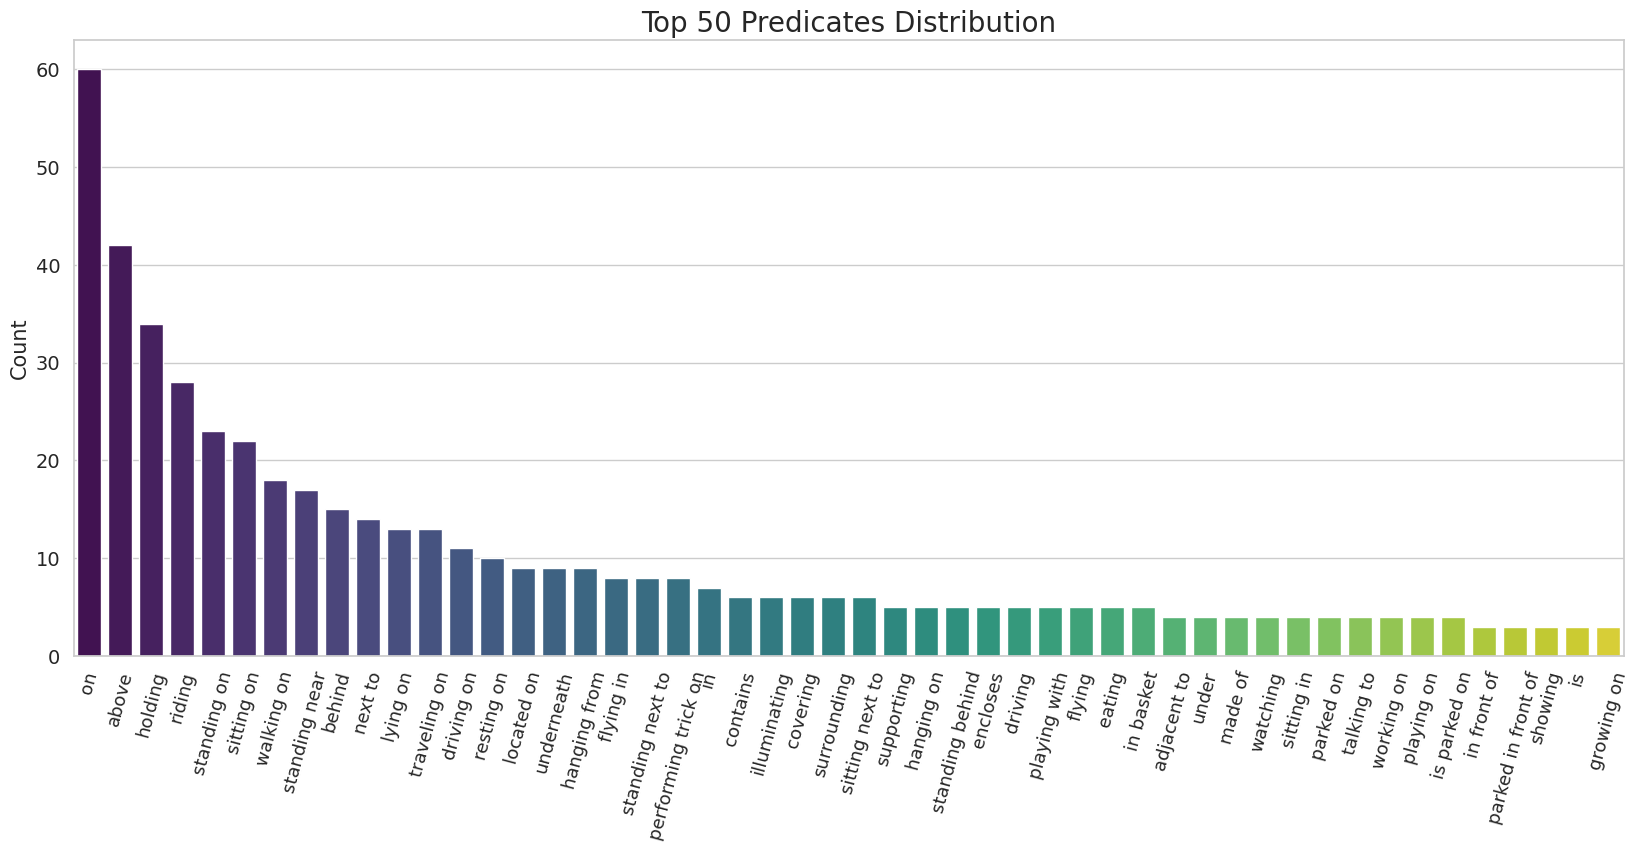

In [ ]:
print(count_predicate.most_common(10))
print(len(count_predicate))

# remove first entry from count_predicate

import seaborn as sns
import matplotlib.pyplot as plt

# display the distribution of the predicates
plt.figure(figsize=(20,8))
sns.set(style="whitegrid")

# Create the barplot
sns.barplot(x=[i[0] for i in count_predicate.most_common(50)], y=[i[1] for i in count_predicate.most_common(50)], palette="viridis")

# Add titles and labels
plt.title('Top 50 Predicates Distribution', fontsize=20)
# plt.xlabel('Predicates', fontsize=15)
plt.ylabel('Count', fontsize=15)

# Rotate x-axis labels for better readability
plt.xticks(rotation=75, fontsize=13)
plt.yticks(fontsize=14)

# Show the plot
plt.show()

In [ ]:
print(data[101]['objects'])

# get the average number of objects per image

obj_count = 0
count_obj = Counter()

for i in tqdm(data):
    obj_count += len(i['objects'])
    for r in i['objects']:
        count_obj[r['names']] += 1

IndexError: list index out of range

/tmp/ipykernel_602037/398758548.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[i[0] for i in count_obj.most_common(50)], y=[i[1] for i in count_obj.most_common(50)], palette="viridis")


[('person', 110138), ('car', 19781), ('sky', 18780), ('tree', 18382), ('wall', 16231), ('chair', 13890), ('building', 11152), ('grass', 10631), ('pavement', 8724), ('bottle', 8120)]
133


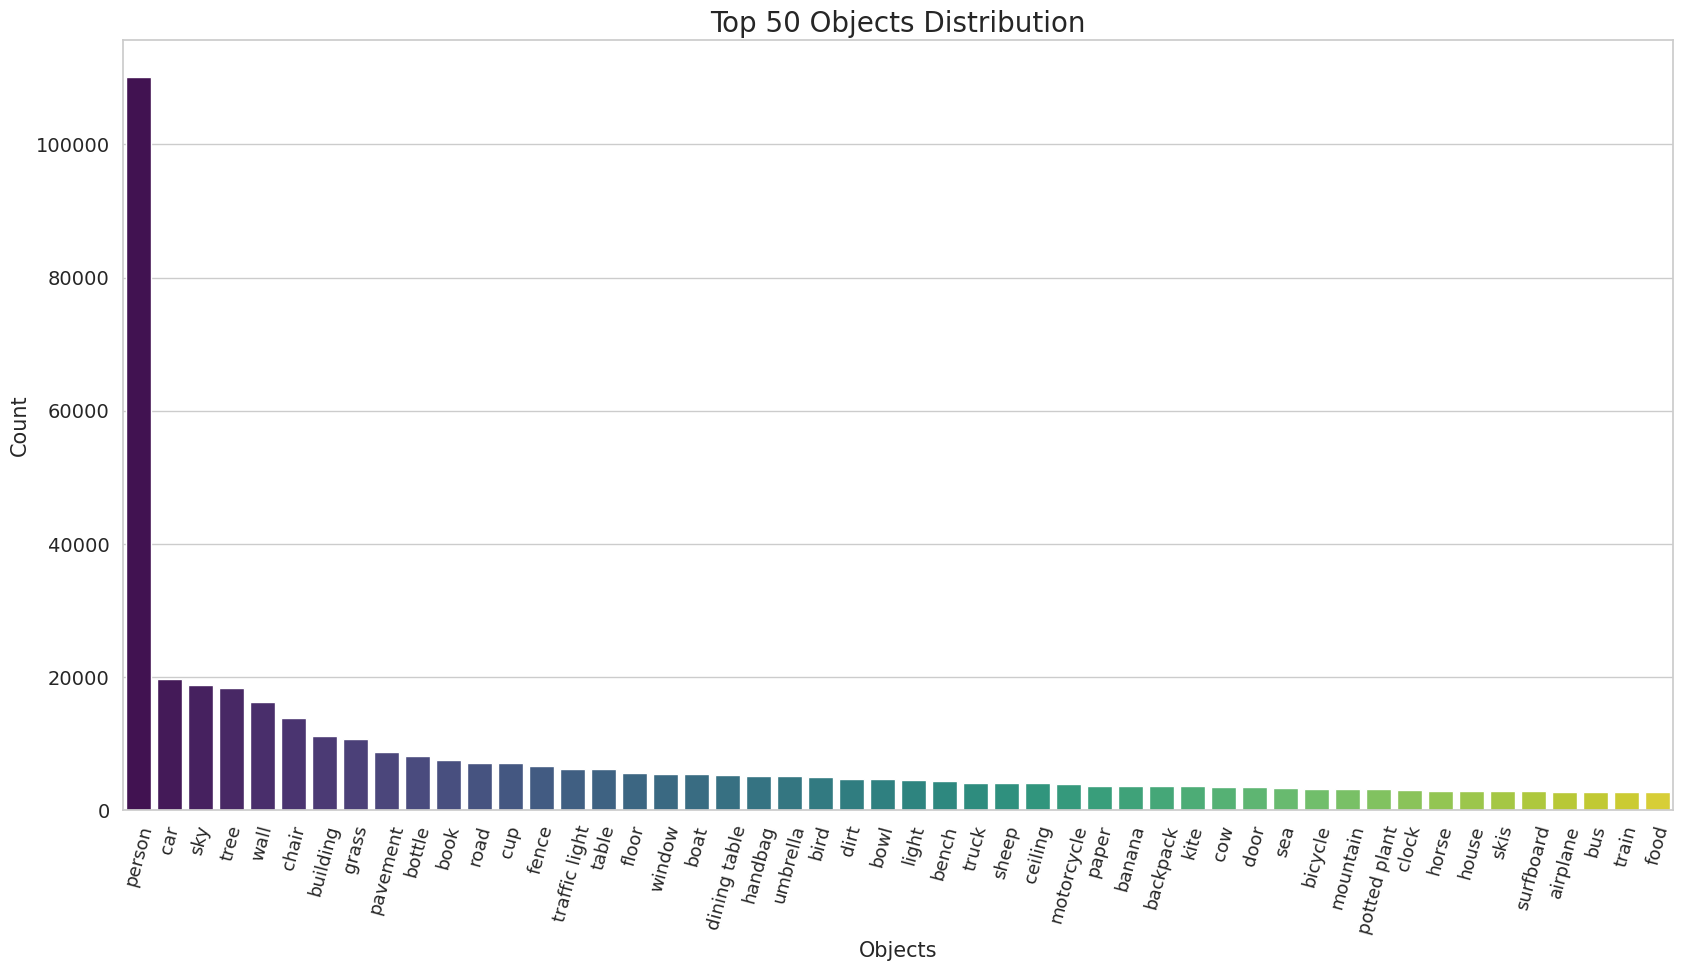

In [ ]:
print(count_obj.most_common(10))
print(len(count_obj))

import seaborn as sns
import matplotlib.pyplot as plt

# display the distribution of the objects

# display the distribution of the predicates
plt.figure(figsize=(20,10))
sns.set(style="whitegrid")

# Create the barplot
sns.barplot(x=[i[0] for i in count_obj.most_common(50)], y=[i[1] for i in count_obj.most_common(50)], palette="viridis")

# Add titles and labels
plt.title('Top 50 Objects Distribution', fontsize=20)
plt.xlabel('Objects', fontsize=15)
plt.ylabel('Count', fontsize=15)

# Rotate x-axis labels for better readability
plt.xticks(rotation=75, fontsize=13)
plt.yticks(fontsize=14)


# Show the plot
plt.show()

# plt.figure(figsize=(20,10))
# sns.barplot(x=[i[0] for i in count_obj.most_common(50)], y=[i[1] for i in count_obj.most_common(50)])
# plt.xticks(rotation=75)
# plt.show()